In [1]:
import pandas as pd
import os

# CSVファイルAとBを読み込む
# ファイルパスを指定してください
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"

csv_a = "Bestmodel_epoch070_per_image_metrics_20260107_1428.csv"
csv_b = "Segmenter_DataAttributes.csv"
output_c = "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed.csv"

csv_a_path = os.path.join(base_dir, csv_a)
csv_b_path = os.path.join(base_dir, csv_b)
output_c_path = os.path.join(base_dir, output_c)

# ファイルAとBを読み込む
df_a = pd.read_csv(csv_a_path)
df_b = pd.read_csv(csv_b_path)

# Aの「image」属性とBの「filename」属性をマッチして左結合
# 左結合により、Aのすべてのデータが保持され、マッチするデータのみBの属性が追加される
df_c = df_a.merge(
    df_b,
    left_on='image',      # Aの「image」属性
    right_on='filename',  # Bの「filename」属性
    how='left'            # 左結合：Aのデータはすべて保持
)

# 結果をファイルCとして出力
df_c.to_csv(output_c_path, index=False)

print(f"結合完了。ファイルC: {output_c_path}")
print(f"A: {len(df_a)}行、B: {len(df_b)}行、C: {len(df_c)}行")

結合完了。ファイルC: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428\Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed.csv
A: 100行、B: 786行、C: 100行


In [ ]:
from scipy.stats import pointbiserialr
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import pandas as pd

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"

csv_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v1.0.csv")

df_c = pd.read_csv(csv_path)

# 説明変数の属性名リスト（11個のカテゴリカル変数）
explanatory_vars = [
    'Roof_Covered',
    'Not_Centered',
    'Intact_House',
    'Cropped_Off',
    'Shady',
    'Dark',
    'Cloudy',
    'Tree',
    'Snow',
    'Objects',
    'Seam'
]

# 目的変数のリスト
target_vars = [
    "loss",
    'mIoU',
    'pixel_acc',
    'mean_acc',
    'iou_class0',
    'iou_class1',
    "precision_class0",
    "precision_class1",
    "recall_class0",
    "recall_class1",
    "f1_class0",
    "f1_class1",
]

# 結果を蓄積するリスト
all_corr_results = []
all_lasso_results = []

# 各目的変数に対して解析を実行
for target_var in target_vars:
    print("\n" + "=" * 80)
    print(f"目的変数: {target_var}")
    print("=" * 80)
    
    # df_cから必要な列を抽出
    df_analysis = df_c[[target_var] + explanatory_vars].dropna()
    
    # ステップ1: 点二列相関を計算
    print("\n" + "=" * 60)
    print("ステップ1: 点二列相関の計算")
    print("=" * 60)
    
    correlations = {}
    for var in explanatory_vars:
        corr, pval = pointbiserialr(df_analysis[var], df_analysis[target_var])
        correlations[var] = {'correlation': corr, 'p_value': pval, 'abs_corr': abs(corr)}
        print(f"{var}: 相関係数 = {corr:.4f}, p値 = {pval:.4f}")
    
    # 相関の低い説明変数を除外（相関係数の絶対値で判定）
    correlation_threshold = 0.05
    selected_vars = [var for var in explanatory_vars 
                     if correlations[var]['abs_corr'] > correlation_threshold]
    
    print(f"\n相関係数の絶対値が {correlation_threshold} より大きい説明変数を選択")
    print(f"除外された変数: {[var for var in explanatory_vars if var not in selected_vars]}")
    print(f"選択された変数: {selected_vars}")
    
    # ステップ2: Lasso回帰の実行
    print("\n" + "=" * 60)
    print("ステップ2: Lasso回帰の実行")
    print("=" * 60)
    
    X = df_analysis[selected_vars].values
    y = df_analysis[target_var].values
    
    # 特徴量の標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Lasso回帰（alpha=0.01）
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_scaled, y)
    
    # 結果の表示
    print(f"Lasso回帰の係数:")
    for i, var in enumerate(selected_vars):
        print(f"  {var}: {lasso.coef_[i]:.6f}")
    print(f"切片: {lasso.intercept_:.6f}")
    print(f"R² スコア: {lasso.score(X_scaled, y):.6f}")
    
    # 相関係数の結果をリストに蓄積
    corr_results_df = pd.DataFrame([
        {
            'Target_Variable': target_var,
            'Explanatory_Variable': var,
            'Correlation': info['correlation'],
            'P_Value': info['p_value'],
            'Abs_Correlation': info['abs_corr'],
            'Selected': 'Yes' if var in selected_vars else 'No'
        }
        for var, info in correlations.items()
    ]).sort_values('Abs_Correlation', ascending=False)
    all_corr_results.append(corr_results_df)
    
    # Lasso回帰の結果をリストに蓄積
    lasso_results_df = pd.DataFrame({
        'Target_Variable': [target_var] * (len(selected_vars) + 1),
        'Variable': ['Intercept'] + selected_vars,
        'Coefficient': [lasso.intercept_] + list(lasso.coef_),
        'Type': ['Intercept'] + ['Feature'] * len(selected_vars)
    })
    all_lasso_results.append(lasso_results_df)

# ステップ3: すべての結果を行列形式に変換して出力
print("\n" + "=" * 80)
print("すべての計算が完了。結果を行列形式でCSVに出力します")
print("=" * 80)

# すべての相関係数の結果を結合
all_corr_df = pd.concat(all_corr_results, ignore_index=True)

# 相関係数を行列形式に変換（行：目的変数、列：説明変数）
corr_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Correlation'
)
corr_matrix_output_path = os.path.join(base_dir, "Correlation_Matrix.csv")
corr_matrix.to_csv(corr_matrix_output_path)
print(f"\n相関係数行列をCSVに出力: {corr_matrix_output_path}")

# 選択状況を行列形式に変換（行：目的変数、列：説明変数）
selected_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Selected',
    aggfunc='first'
)
selected_matrix_output_path = os.path.join(base_dir, "Variable_Selection_Matrix.csv")
selected_matrix.to_csv(selected_matrix_output_path)
print(f"変数選択状況行列をCSVに出力: {selected_matrix_output_path}")

# p値を行列形式に変換（行：目的変数、列：説明変数）
pval_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='P_Value'
)
pval_matrix_output_path = os.path.join(base_dir, "P_Value_Matrix.csv")
pval_matrix.to_csv(pval_matrix_output_path)
print(f"p値行列をCSVに出力: {pval_matrix_output_path}")

# すべてのLasso回帰の結果を結合
all_lasso_df = pd.concat(all_lasso_results, ignore_index=True)

# Intercept（切片）を除外して係数のみを行列形式に変換
lasso_coef_df = all_lasso_df[all_lasso_df['Type'] == 'Feature'].copy()
lasso_matrix = lasso_coef_df.pivot_table(
    index='Target_Variable',
    columns='Variable',
    values='Coefficient'
)
lasso_matrix_output_path = os.path.join(base_dir, "Lasso_Coefficient_Matrix.csv")
lasso_matrix.to_csv(lasso_matrix_output_path)
print(f"\nLasso係数行列をCSVに出力: {lasso_matrix_output_path}")

# 切片（Intercept）を別に出力
intercept_df = all_lasso_df[all_lasso_df['Type'] == 'Intercept'].copy()
intercept_matrix = intercept_df[['Target_Variable', 'Coefficient']].set_index('Target_Variable')
intercept_matrix.columns = ['Intercept']
intercept_output_path = os.path.join(base_dir, "Lasso_Intercept.csv")
intercept_matrix.to_csv(intercept_output_path)
print(f"Lasso切片をCSVに出力: {intercept_output_path}")


目的変数: loss

ステップ1: 点二列相関の計算
Roof_Covered: 相関係数 = 0.1312, p値 = 0.1933
Not_Centered: 相関係数 = -0.0125, p値 = 0.9021
Intact_House: 相関係数 = -0.1548, p値 = 0.1242
Cropped_Off: 相関係数 = 0.1551, p値 = 0.1233
Shady: 相関係数 = 0.0581, p値 = 0.5656
Dark: 相関係数 = 0.1456, p値 = 0.1483
Cloudy: 相関係数 = -0.0728, p値 = 0.4716
Tree: 相関係数 = -0.1502, p値 = 0.1358
Snow: 相関係数 = -0.0564, p値 = 0.5774
Objects: 相関係数 = -0.1347, p値 = 0.1814
Seam: 相関係数 = -0.0383, p値 = 0.7051

相関係数の絶対値が 0.05 より大きい説明変数を選択
除外された変数: ['Not_Centered', 'Seam']
選択された変数: ['Roof_Covered', 'Intact_House', 'Cropped_Off', 'Shady', 'Dark', 'Cloudy', 'Tree', 'Snow', 'Objects']

ステップ2: Lasso回帰の実行
Lasso回帰の係数:
  Roof_Covered: 0.010768
  Intact_House: -0.013091
  Cropped_Off: 0.012501
  Shady: 0.000855
  Dark: 0.010415
  Cloudy: -0.000000
  Tree: -0.013697
  Snow: -0.000043
  Objects: -0.009804
切片: 0.370221
R² スコア: 0.093416

目的変数: mIoU

ステップ1: 点二列相関の計算
Roof_Covered: 相関係数 = -0.1151, p値 = 0.2543
Not_Centered: 相関係数 = 0.0509, p値 = 0.6152
Intact_House: 相関係数 = 0.1671, p

In [ ]:
from scipy.stats import pointbiserialr
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import pandas as pd

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"

csv_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v1.0.csv")

df_c = pd.read_csv(csv_path)

# 説明変数の属性名リスト（11個のカテゴリカル変数）
explanatory_vars = [
    'Roof_Covered',
    'Not_Centered',
    'Intact_House',
    'Cropped_Off',
    'Shady',
    'Dark',
    'Cloudy',
    'Tree',
    'Snow',
    'Objects',
    'Seam'
]

# 目的変数のリスト
target_vars = [
    "loss",
    'mIoU',
    'pixel_acc',
    'mean_acc',
    'iou_class0',
    'iou_class1',
    "precision_class0",
    "precision_class1",
    "recall_class0",
    "recall_class1",
    "f1_class0",
    "f1_class1",
]

# 結果を蓄積するリスト
all_corr_results = []
all_lasso_results = []

# 各目的変数に対して解析を実行
for target_var in target_vars:
    print("\n" + "=" * 80)
    print(f"目的変数: {target_var}")
    print("=" * 80)
    
    # df_cから必要な列を抽出
    df_analysis = df_c[[target_var] + explanatory_vars].dropna()
    
    # ステップ1: 点二列相関を計算
    print("\n" + "=" * 60)
    print("ステップ1: 点二列相関の計算")
    print("=" * 60)
    
    correlations = {}
    for var in explanatory_vars:
        corr, pval = pointbiserialr(df_analysis[var], df_analysis[target_var])
        correlations[var] = {'correlation': corr, 'p_value': pval, 'abs_corr': abs(corr)}
        print(f"{var}: 相関係数 = {corr:.4f}, p値 = {pval:.4f}")
    
    # 相関の低い説明変数を除外（相関係数の絶対値で判定）
    correlation_threshold = 0.05
    selected_vars = [var for var in explanatory_vars 
                     if correlations[var]['abs_corr'] > correlation_threshold]
    
    print(f"\n相関係数の絶対値が {correlation_threshold} より大きい説明変数を選択")
    print(f"除外された変数: {[var for var in explanatory_vars if var not in selected_vars]}")
    print(f"選択された変数: {selected_vars}")
    
    # ステップ2: Lasso回帰の実行
    print("\n" + "=" * 60)
    print("ステップ2: Lasso回帰の実行")
    print("=" * 60)
    
    X = df_analysis[selected_vars].values
    y = df_analysis[target_var].values
    
    # 特徴量の標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Lasso回帰（alpha=0.01）
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_scaled, y)
    
    # 結果の表示
    print(f"Lasso回帰の係数:")
    for i, var in enumerate(selected_vars):
        print(f"  {var}: {lasso.coef_[i]:.6f}")
    print(f"切片: {lasso.intercept_:.6f}")
    print(f"R² スコア: {lasso.score(X_scaled, y):.6f}")
    
    # 相関係数の結果をリストに蓄積
    corr_results_df = pd.DataFrame([
        {
            'Target_Variable': target_var,
            'Explanatory_Variable': var,
            'Correlation': info['correlation'],
            'P_Value': info['p_value'],
            'Abs_Correlation': info['abs_corr'],
            'Selected': 'Yes' if var in selected_vars else 'No'
        }
        for var, info in correlations.items()
    ]).sort_values('Abs_Correlation', ascending=False)
    all_corr_results.append(corr_results_df)
    
    # Lasso回帰の結果をリストに蓄積
    lasso_results_df = pd.DataFrame({
        'Target_Variable': [target_var] * (len(selected_vars) + 1),
        'Variable': ['Intercept'] + selected_vars,
        'Coefficient': [lasso.intercept_] + list(lasso.coef_),
        'Type': ['Intercept'] + ['Feature'] * len(selected_vars)
    })
    all_lasso_results.append(lasso_results_df)

# ステップ3: すべての結果を行列形式に変換して出力
print("\n" + "=" * 80)
print("すべての計算が完了。結果を行列形式でCSVに出力します")
print("=" * 80)

# すべての相関係数の結果を結合
all_corr_df = pd.concat(all_corr_results, ignore_index=True)

# 相関係数を行列形式に変換（行：目的変数、列：説明変数）
corr_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Correlation'
)
corr_matrix_output_path = os.path.join(base_dir, "Correlation_Matrix.csv")
corr_matrix.to_csv(corr_matrix_output_path)
print(f"\n相関係数行列をCSVに出力: {corr_matrix_output_path}")

# 選択状況を行列形式に変換（行：目的変数、列：説明変数）
selected_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Selected',
    aggfunc='first'
)
selected_matrix_output_path = os.path.join(base_dir, "Variable_Selection_Matrix.csv")
selected_matrix.to_csv(selected_matrix_output_path)
print(f"変数選択状況行列をCSVに出力: {selected_matrix_output_path}")

# p値を行列形式に変換（行：目的変数、列：説明変数）
pval_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='P_Value'
)
pval_matrix_output_path = os.path.join(base_dir, "P_Value_Matrix.csv")
pval_matrix.to_csv(pval_matrix_output_path)
print(f"p値行列をCSVに出力: {pval_matrix_output_path}")

# すべてのLasso回帰の結果を結合
all_lasso_df = pd.concat(all_lasso_results, ignore_index=True)

# Intercept（切片）を除外して係数のみを行列形式に変換
lasso_coef_df = all_lasso_df[all_lasso_df['Type'] == 'Feature'].copy()
lasso_matrix = lasso_coef_df.pivot_table(
    index='Target_Variable',
    columns='Variable',
    values='Coefficient'
)
lasso_matrix_output_path = os.path.join(base_dir, "Lasso_Coefficient_Matrix.csv")
lasso_matrix.to_csv(lasso_matrix_output_path)
print(f"\nLasso係数行列をCSVに出力: {lasso_matrix_output_path}")

# 切片（Intercept）を別に出力
intercept_df = all_lasso_df[all_lasso_df['Type'] == 'Intercept'].copy()
intercept_matrix = intercept_df[['Target_Variable', 'Coefficient']].set_index('Target_Variable')
intercept_matrix.columns = ['Intercept']
intercept_output_path = os.path.join(base_dir, "Lasso_Intercept.csv")
intercept_matrix.to_csv(intercept_output_path)
print(f"Lasso切片をCSVに出力: {intercept_output_path}")


目的変数: loss

ステップ1: 点二列相関の計算
Roof_Covered: 相関係数 = 0.1312, p値 = 0.1933
Not_Centered: 相関係数 = -0.0125, p値 = 0.9021
Intact_House: 相関係数 = -0.1548, p値 = 0.1242
Cropped_Off: 相関係数 = 0.1551, p値 = 0.1233
Shady: 相関係数 = 0.0581, p値 = 0.5656
Dark: 相関係数 = 0.1456, p値 = 0.1483
Cloudy: 相関係数 = -0.0728, p値 = 0.4716
Tree: 相関係数 = -0.1502, p値 = 0.1358
Snow: 相関係数 = -0.0564, p値 = 0.5774
Objects: 相関係数 = -0.1347, p値 = 0.1814
Seam: 相関係数 = -0.0383, p値 = 0.7051

相関係数の絶対値が 0.05 より大きい説明変数を選択
除外された変数: ['Not_Centered', 'Seam']
選択された変数: ['Roof_Covered', 'Intact_House', 'Cropped_Off', 'Shady', 'Dark', 'Cloudy', 'Tree', 'Snow', 'Objects']

ステップ2: Lasso回帰の実行
Lasso回帰の係数:
  Roof_Covered: 0.010768
  Intact_House: -0.013091
  Cropped_Off: 0.012501
  Shady: 0.000855
  Dark: 0.010415
  Cloudy: -0.000000
  Tree: -0.013697
  Snow: -0.000043
  Objects: -0.009804
切片: 0.370221
R² スコア: 0.093416

目的変数: mIoU

ステップ1: 点二列相関の計算
Roof_Covered: 相関係数 = -0.1151, p値 = 0.2543
Not_Centered: 相関係数 = 0.0509, p値 = 0.6152
Intact_House: 相関係数 = 0.1671, p

In [4]:
import re, os

# セル2と同じパスのCSVファイルを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"

csv_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v1.0.csv")
df = pd.read_csv(csv_path)

# TNとFPから最初の数字を抽出する関数
def extract_first_number(value):
    """
    '[ 513. 2394.]' という形式から最初の数字（513）を抽出
    """
    if pd.isna(value):
        return None
    # 文字列に変換（念のため）
    value_str = str(value)
    # 正規表現で最初の数字を抽出
    match = re.search(r'\[\s*([\d.]+)', value_str)
    if match:
        return float(match.group(1))
    return None

# TN と FP から最初の数字を抽出
df['TN_value'] = df['TN'].apply(extract_first_number)
df['FP_value'] = df['FP'].apply(extract_first_number)

# TN + FP を計算し、4096で割る
df['class1_px_percentage'] = (df['TN_value'] + df['FP_value']) / 4096

# 確認：計算結果を表示
print(f"処理完了。{len(df)}行のデータを処理しました。")
print(f"\nサンプルデータ:")
print(df[['TN', 'FP', 'TN_value', 'FP_value', 'class1_px_percentage']].head(10))

# 結果をCSVに出力（オプション）
output_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v2.0.csv")
df.to_csv(output_path, index=False)
print(f"\n結果を保存: {output_path}")

処理完了。100行のデータを処理しました。

サンプルデータ:
              TN             FP  TN_value  FP_value  class1_px_percentage
0  [   0. 3646.]    [332. 118.]       0.0     332.0              0.081055
1  [ 513. 2394.]  [1067.  122.]     513.0    1067.0              0.385742
2  [  62. 2732.]    [382. 920.]      62.0     382.0              0.108398
3  [ 547. 3010.]    [402. 137.]     547.0     402.0              0.231689
4  [ 225. 2564.]  [1035.  272.]     225.0    1035.0              0.307617
5  [ 379. 2989.]    [514. 214.]     379.0     514.0              0.218018
6  [   0. 2657.]    [766. 673.]       0.0     766.0              0.187012
7  [   0. 3596.]    [341. 159.]       0.0     341.0              0.083252
8  [   0. 3426.]    [367. 303.]       0.0     367.0              0.089600
9  [   0. 4096.]        [0. 0.]       0.0       0.0              0.000000

結果を保存: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428\Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed

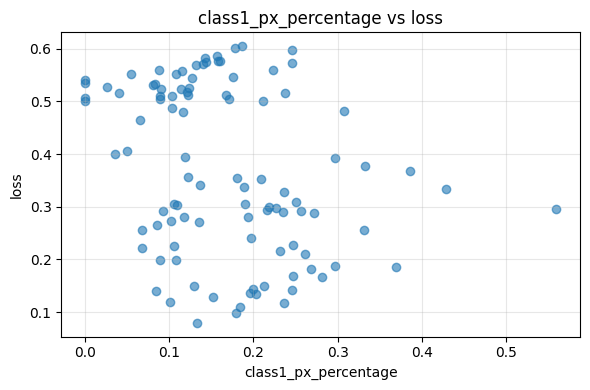

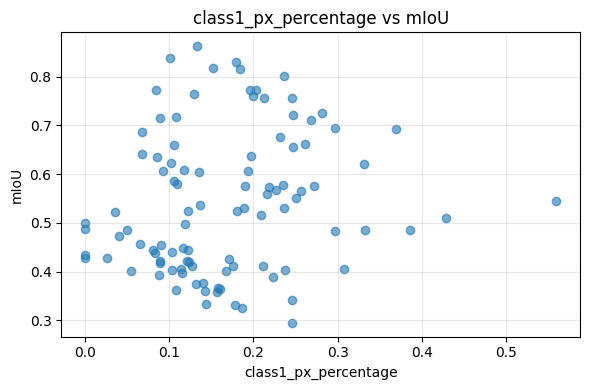

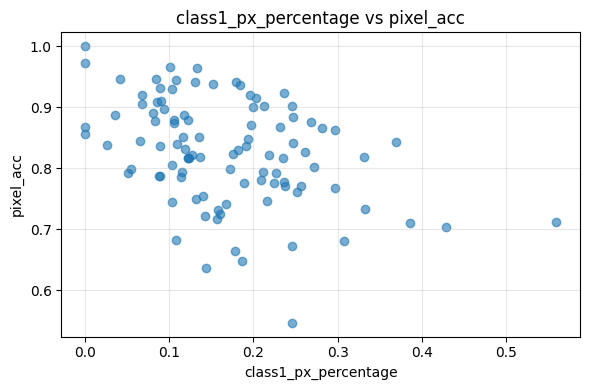

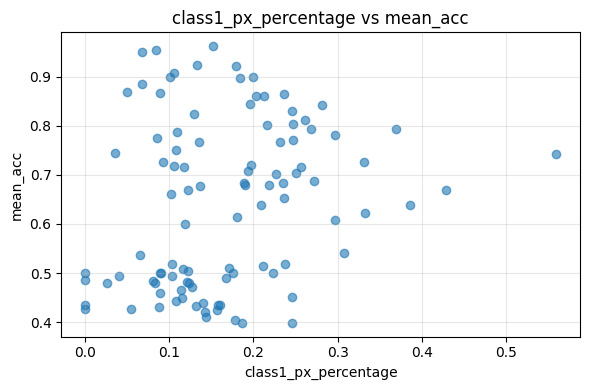

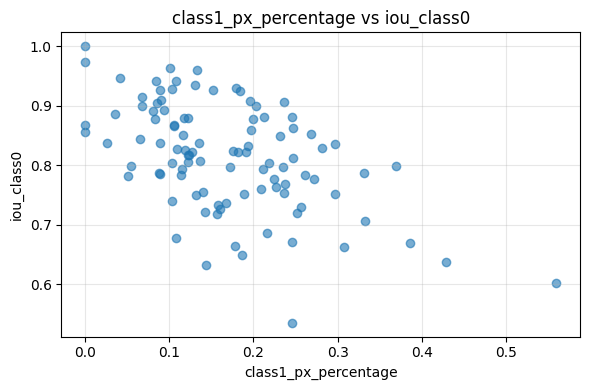

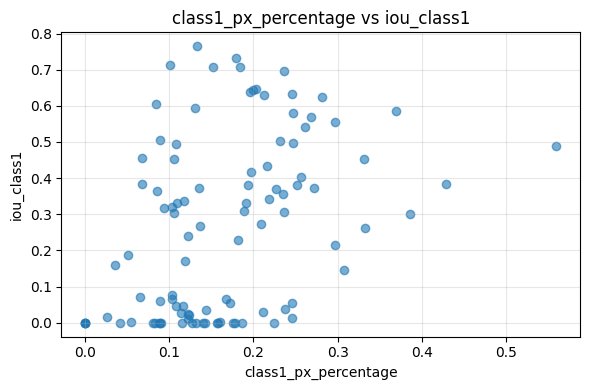

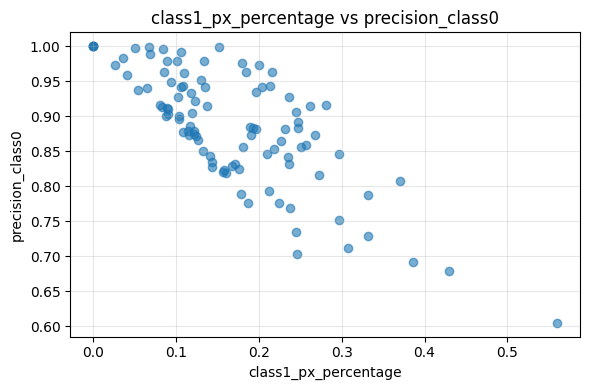

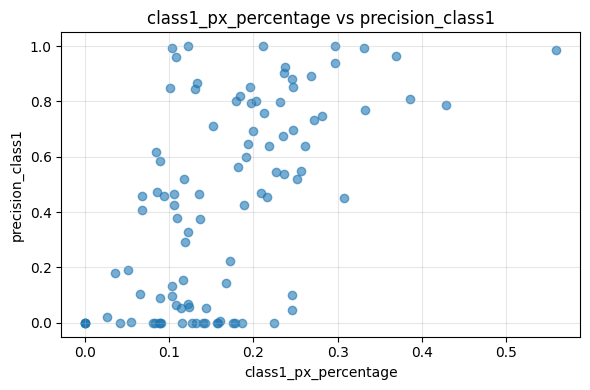

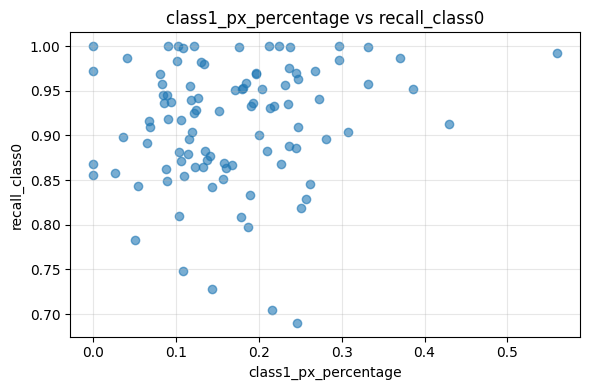

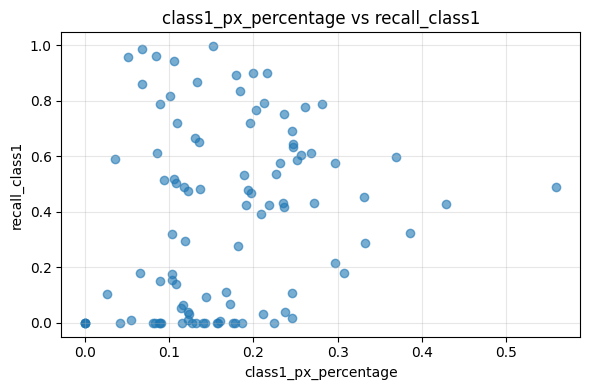

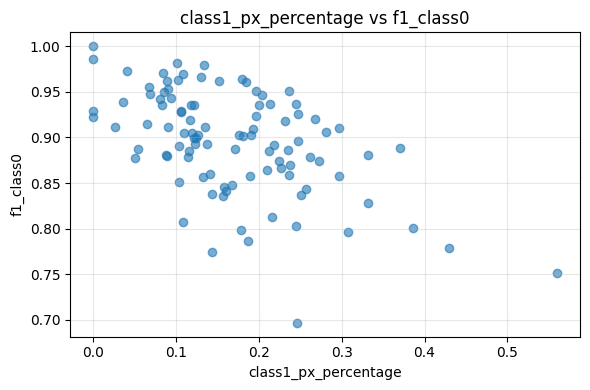

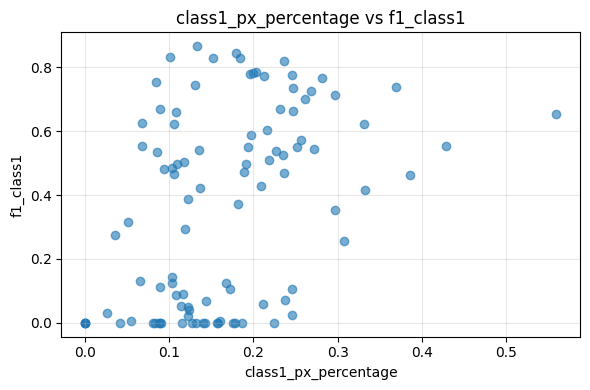

CSV: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428\Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v2.0.csv
目的変数: class1_px_percentage

相関結果（|r|降順）:


,variable,pearson_r,p_value,n,note
6,precision_class0,-0.755743,1.015603e-19,100,
7,precision_class1,0.582174,2.110113e-10,100,
10,f1_class0,-0.529851,1.438506e-08,100,
4,iou_class0,-0.529040,1.527321e-08,100,
11,f1_class1,0.416300,1.648133e-05,100,
2,pixel_acc,-0.398187,4.081572e-05,100,
5,iou_class1,0.391103,5.737848e-05,100,
0,loss,-0.304171,2.092953e-03,100,
3,mean_acc,0.227700,2.270347e-02,100,
9,recall_class1,0.205312,4.044364e-02,100,



保存: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428\Correlation_class1_px_percentage_vs_continuous.csv


: 

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# CSV読み込み（必要に応じてファイル名を変更してください）
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"
csv_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v2.0.csv")

df = pd.read_csv(csv_path)

# ================================
# ここに「連続量（数値）」の列名を手動で入力してください
# 例: ['loss', 'mIoU', 'pixel_acc', ...]
# ================================
continuous_vars = [
    'loss',
    'mIoU',
    'pixel_acc',
    'mean_acc',
    "iou_class0",
    "iou_class1",
    "precision_class0",
    "precision_class1",
    "recall_class0",
    "recall_class1",
    "f1_class0",
    "f1_class1"
]

target_col = "class1_px_percentage"

if target_col not in df.columns:
    raise KeyError(f"{target_col} がCSVに存在しません。列一覧: {list(df.columns)}")

# 相関計算（Pearson）
results = []
for col in continuous_vars:
    if col not in df.columns:
        results.append({"variable": col, "pearson_r": np.nan, "p_value": np.nan, "n": 0, "note": "列が存在しません"})
        continue

    x = pd.to_numeric(df[target_col], errors="coerce")
    y = pd.to_numeric(df[col], errors="coerce")

    valid = x.notna() & y.notna()
    n = int(valid.sum())

    if valid.sum() == 0:
           print(f"{col}: 有効なデータがないためプロットをスキップします。")
           continue

    plt.figure(figsize=(6, 4))
    plt.scatter(x[valid], y[valid], alpha=0.6)
    plt.xlabel(target_col)
    plt.ylabel(col)
    plt.title(f"{target_col} vs {col}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if n < 3:
        results.append({"variable": col, "pearson_r": np.nan, "p_value": np.nan, "n": n, "note": "有効データ不足(n<3)"})
        continue

    r, p = pearsonr(x[valid].values, y[valid].values)
    results.append({"variable": col, "pearson_r": float(r), "p_value": float(p), "n": n, "note": ""})

res_df = pd.DataFrame(results)
res_df["abs_r"] = res_df["pearson_r"].abs()
res_df = res_df.sort_values("abs_r", ascending=False)

print(f"CSV: {csv_path}")
print(f"目的変数: {target_col}")
print("\n相関結果（|r|降順）:")
display(res_df[["variable", "pearson_r", "p_value", "n", "note"]])

# 保存（必要なら）
out_path = os.path.join(base_dir, "Correlation_class1_px_percentage_vs_continuous.csv")
res_df.to_csv(out_path, index=False)
print(f"\n保存: {out_path}")



In [1]:
from scipy.stats import pointbiserialr
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import pandas as pd

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_Segmentation\20260107_1428"

csv_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v3.0.csv")

df_c = pd.read_csv(csv_path)

# 説明変数の属性名リスト（11個のカテゴリカル変数）
explanatory_vars = [
    'GT_multi',
    'GT_float',
    'GT_NoMask',
    'Pred_Multi',
    'Pred_float',
    'Pred_NoMask',
    'Pred_jitter',
    'Multi_True',
    'Float_True',
]

# 目的変数のリスト
target_vars = [
    "loss",
    'mIoU',
    'pixel_acc',
    'mean_acc',
    'iou_class0',
    'iou_class1',
    "precision_class0",
    "precision_class1",
    "recall_class0",
    "recall_class1",
    "f1_class0",
    "f1_class1",
]

# 結果を蓄積するリスト
all_corr_results = []
all_lasso_results = []

# 各目的変数に対して解析を実行
for target_var in target_vars:
    print("\n" + "=" * 80)
    print(f"目的変数: {target_var}")
    print("=" * 80)
    
    # df_cから必要な列を抽出
    df_analysis = df_c[[target_var] + explanatory_vars].dropna()
    
    # ステップ1: 点二列相関を計算
    print("\n" + "=" * 60)
    print("ステップ1: 点二列相関の計算")
    print("=" * 60)
    
    correlations = {}
    for var in explanatory_vars:
        corr, pval = pointbiserialr(df_analysis[var], df_analysis[target_var])
        correlations[var] = {'correlation': corr, 'p_value': pval, 'abs_corr': abs(corr)}
        print(f"{var}: 相関係数 = {corr:.4f}, p値 = {pval:.4f}")
    
    # 相関の低い説明変数を除外（相関係数の絶対値で判定）
    correlation_threshold = 0.05
    selected_vars = [var for var in explanatory_vars 
                     if correlations[var]['abs_corr'] > correlation_threshold]
    
    print(f"\n相関係数の絶対値が {correlation_threshold} より大きい説明変数を選択")
    print(f"除外された変数: {[var for var in explanatory_vars if var not in selected_vars]}")
    print(f"選択された変数: {selected_vars}")
    
    # ステップ2: Lasso回帰の実行
    print("\n" + "=" * 60)
    print("ステップ2: Lasso回帰の実行")
    print("=" * 60)
    
    X = df_analysis[selected_vars].values
    y = df_analysis[target_var].values
    
    # 特徴量の標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Lasso回帰（alpha=0.01）
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_scaled, y)
    
    # 結果の表示
    print(f"Lasso回帰の係数:")
    for i, var in enumerate(selected_vars):
        print(f"  {var}: {lasso.coef_[i]:.6f}")
    print(f"切片: {lasso.intercept_:.6f}")
    print(f"R² スコア: {lasso.score(X_scaled, y):.6f}")
    
    # 相関係数の結果をリストに蓄積
    corr_results_df = pd.DataFrame([
        {
            'Target_Variable': target_var,
            'Explanatory_Variable': var,
            'Correlation': info['correlation'],
            'P_Value': info['p_value'],
            'Abs_Correlation': info['abs_corr'],
            'Selected': 'Yes' if var in selected_vars else 'No'
        }
        for var, info in correlations.items()
    ]).sort_values('Abs_Correlation', ascending=False)
    all_corr_results.append(corr_results_df)
    
    # Lasso回帰の結果をリストに蓄積
    lasso_results_df = pd.DataFrame({
        'Target_Variable': [target_var] * (len(selected_vars) + 1),
        'Variable': ['Intercept'] + selected_vars,
        'Coefficient': [lasso.intercept_] + list(lasso.coef_),
        'Type': ['Intercept'] + ['Feature'] * len(selected_vars)
    })
    all_lasso_results.append(lasso_results_df)

# ステップ3: すべての結果を行列形式に変換して出力
print("\n" + "=" * 80)
print("すべての計算が完了。結果を行列形式でCSVに出力します")
print("=" * 80)

# すべての相関係数の結果を結合
all_corr_df = pd.concat(all_corr_results, ignore_index=True)

# 相関係数を行列形式に変換（行：目的変数、列：説明変数）
corr_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Correlation'
)
corr_matrix_output_path = os.path.join(base_dir, "Correlation_Matrix.csv")
corr_matrix.to_csv(corr_matrix_output_path)
print(f"\n相関係数行列をCSVに出力: {corr_matrix_output_path}")

# 選択状況を行列形式に変換（行：目的変数、列：説明変数）
selected_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='Selected',
    aggfunc='first'
)
selected_matrix_output_path = os.path.join(base_dir, "Variable_Selection_Matrix.csv")
selected_matrix.to_csv(selected_matrix_output_path)
print(f"変数選択状況行列をCSVに出力: {selected_matrix_output_path}")

# p値を行列形式に変換（行：目的変数、列：説明変数）
pval_matrix = all_corr_df.pivot_table(
    index='Target_Variable',
    columns='Explanatory_Variable',
    values='P_Value'
)
pval_matrix_output_path = os.path.join(base_dir, "P_Value_Matrix.csv")
pval_matrix.to_csv(pval_matrix_output_path)
print(f"p値行列をCSVに出力: {pval_matrix_output_path}")

# すべてのLasso回帰の結果を結合
all_lasso_df = pd.concat(all_lasso_results, ignore_index=True)

# Intercept（切片）を除外して係数のみを行列形式に変換
lasso_coef_df = all_lasso_df[all_lasso_df['Type'] == 'Feature'].copy()
lasso_matrix = lasso_coef_df.pivot_table(
    index='Target_Variable',
    columns='Variable',
    values='Coefficient'
)
lasso_matrix_output_path = os.path.join(base_dir, "Lasso_Coefficient_Matrix.csv")
lasso_matrix.to_csv(lasso_matrix_output_path)
print(f"\nLasso係数行列をCSVに出力: {lasso_matrix_output_path}")

# 切片（Intercept）を別に出力
intercept_df = all_lasso_df[all_lasso_df['Type'] == 'Intercept'].copy()
intercept_matrix = intercept_df[['Target_Variable', 'Coefficient']].set_index('Target_Variable')
intercept_matrix.columns = ['Intercept']
intercept_output_path = os.path.join(base_dir, "Lasso_Intercept.csv")
intercept_matrix.to_csv(intercept_output_path)
print(f"Lasso切片をCSVに出力: {intercept_output_path}")


目的変数: loss

ステップ1: 点二列相関の計算
GT_multi: 相関係数 = -0.1855, p値 = 0.0646
GT_float: 相関係数 = -0.0419, p値 = 0.6791
GT_NoMask: 相関係数 = 0.1937, p値 = 0.0534
Pred_Multi: 相関係数 = -0.0084, p値 = 0.9340
Pred_float: 相関係数 = -0.0516, p値 = 0.6103
Pred_NoMask: 相関係数 = 0.1746, p値 = 0.0823
Pred_jitter: 相関係数 = 0.1621, p値 = 0.1070
Multi_True: 相関係数 = -0.0592, p値 = 0.5585
Float_True: 相関係数 = -0.1127, p値 = 0.2642

相関係数の絶対値が 0.05 より大きい説明変数を選択
除外された変数: ['GT_float', 'Pred_Multi']
選択された変数: ['GT_multi', 'GT_NoMask', 'Pred_float', 'Pred_NoMask', 'Pred_jitter', 'Multi_True', 'Float_True']

ステップ2: Lasso回帰の実行
Lasso回帰の係数:
  GT_multi: -0.021874
  GT_NoMask: 0.016376
  Pred_float: -0.004343
  Pred_NoMask: 0.016156
  Pred_jitter: 0.024464
  Multi_True: -0.007116
  Float_True: -0.015624
切片: 0.370221
R² スコア: 0.145721

目的変数: mIoU

ステップ1: 点二列相関の計算
GT_multi: 相関係数 = 0.1621, p値 = 0.1072
GT_float: 相関係数 = 0.0159, p値 = 0.8755
GT_NoMask: 相関係数 = -0.1120, p値 = 0.2674
Pred_Multi: 相関係数 = -0.0360, p値 = 0.7225
Pred_float: 相関係数 = 0.0309, p値 = 0.7604